<a href="https://colab.research.google.com/github/HoFangHuy/AI/blob/main/BTVN-nhandienhoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

In [5]:
!pip install matplotlib
!pip install scikit-learn

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

In [6]:
from google.colab import files
import zipfile
import os

# Upload file .zip chứa ảnh các loại hoa
uploaded = files.upload()

# Giải nén thư mục
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall("/content/flower_data")

# Kiểm tra thư mục sau khi giải nén
os.listdir("/content/flower_data")


Saving ảnh train model.zip to ảnh train model.zip


['ảnh train model']

In [10]:
import zipfile
import os

zip_path = "/content/ảnh train model.zip"  # hoặc sửa tên file zip nếu khác
extract_path = "/content/hoa_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Giải nén xong!")

✅ Giải nén xong!


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Tên các lớp (class)
classes = sorted(os.listdir("/content/hoa_data/ảnh train model"))  # ví dụ: "hoa cúc", "hoa hồng",...
print("Lớp:", classes)

img_size = (100, 100)
X = []
y = []

# Load ảnh
for i, label in enumerate(classes):
    folder = os.path.join("/content/hoa_data/ảnh train model", label)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        try:
            img = load_img(img_path, target_size=img_size)
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(i)
        except:
            print("Lỗi ảnh:", img_path)

X = np.array(X)
y = to_categorical(y)

# Tách tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng mô hình ANN
model = Sequential([
    Flatten(input_shape=img_size + (3,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Lớp: ['hoa hồng', 'hoa lan', 'hoa mai', 'hoa sen', 'hoa vạn thọ']
Lỗi ảnh: /content/hoa_data/ảnh train model/hoa mai/7.htm


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 30000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,840,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,848,709 (14.68 MB)

 Trainable params: 3,848,709 (14.68 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - accuracy: 0.1864 - loss: 4.1421 - val_accuracy: 0.2500 - val_loss: 18.1164
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.3482 - loss: 9.9147 - val_accuracy: 0.2500 - val_loss: 5.5242
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.3879 - loss: 4.8368 - val_accuracy: 0.0833 - val_loss: 8.7149
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4437 - loss: 7.0476 - val_accuracy: 0.5833 - val_loss: 3.7479
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.6755 - loss: 3.1195 - val_accuracy: 0.2500 - val_loss: 3.4162
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5146 - loss: 1.6534 - val_accuracy: 0.2500 - val_loss: 3.2021
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5421 - loss: 1.5144 - val_accuracy: 0.2500 - val_loss: 2.2194
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7777 - loss: 1.1594 - val_accuracy: 0.4167 - val_loss

In [14]:
model.save("nhan_dien_hoa.h5")

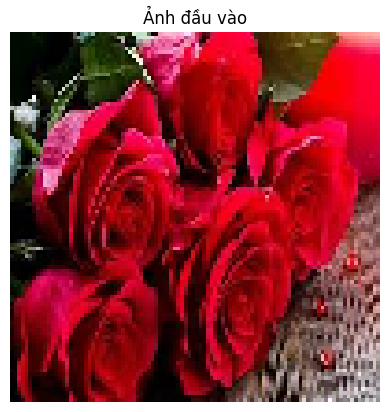

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Loại hoa dự đoán: hoa hồng


In [15]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt


img_path = "/content/th.jpg"

img = load_img(img_path, target_size=img_size)
plt.imshow(img)
plt.axis('off')
plt.title("Ảnh đầu vào")
plt.show()


img = img_to_array(img) / 255.0
img = np.expand_dims(img, axis=0)

pred = model.predict(img)
label = classes[np.argmax(pred)]
print("Loại hoa dự đoán:", label)
